https://github.com/krlawrence/graph/blob/master/sample-data/air-routes-latest-nodes.csv

#Import Libraries

In [5]:
from google.colab import drive
#drive.mount('/content/drive')
!pip install dgl
!pip install node2vec

In [6]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import os

from gensim.models import Word2Vec
from node2vec import Node2Vec

import torch
from torch import tensor
import torch.nn as nn
import torch.nn.functional as F

import dgl
import dgl.nn as dglnn
import dgl.function as fn
from sklearn.feature_extraction.text import CountVectorizer

import scipy.sparse as sp

%matplotlib inline
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_fscore_support, accuracy_score

# Create Graph from DataFrames

In [7]:
# Define the paths to your CSV files
edges_path = "/content/drive/MyDrive/[3] Colab Notebooks/Airline Link Prediction GNN/air-routes-latest-edges.csv"
nodes_path = "/content/drive/MyDrive/[3] Colab Notebooks/Airline Link Prediction GNN/air-routes-latest-nodes.csv"
#three_letter_code_path = "/content/drive/MyDrive/[3] Colab Notebooks/Airline Problem/wikipedia-iso-country-codes.csv"

# Load the data from CSV files into Pandas DataFrames
edges_df = pd.read_csv(edges_path)
nodes_df = pd.read_csv(nodes_path)
#three_letter_df = pd.read_csv(three_letter_code_path)
#nodes_df = pd.merge(nodes_df, three_letter_df, how='left', left_on='country:string', right_on='Alpha-2 code')


# Remove the first row (index 0) from both DataFrames
edges_df = edges_df.iloc[1:]
nodes_df = nodes_df.iloc[1:]
nodes_df["location"] = nodes_df.apply(lambda row: (row["lon:double"],row["lat:double"]), axis=1)


# Filter the nodes_df to include only nodes with "type:string" label of "airport"
nodes_df = nodes_df[nodes_df['type:string'] == 'airport']
# Filter the edges_df to exclude rows where "~from" or "~to" fields are >= 3505
edges_df = edges_df[(edges_df['~from'] < 3505) & (edges_df['~to'] < 3505)]


#filter data for more efficient iteration
nodes_df = nodes_df[['~id','country:string', 'desc:string', 'city:string','location']]
edges_df = edges_df[['~from', '~to','dist:int']]
nodes_df.columns = ['id', 'area_code', 'airport', 'city','location']
nodes_df.set_index('id', inplace=True)
edges_df.columns = ['from', 'to', 'distance']



#print(nodes_df.head())
# Create an empty NetworkX graph
G = nx.Graph()  # You can use DiGraph or MultiGraph if your data represents directed or multi-edges.

# Add nodes to the graph with labels and attributes
for index, row in nodes_df.iterrows():
    node_id = index
    country_key = row['area_code']
    airport = row['airport']
    city = row['city']
    locat = row['location']
    G.add_node(node_id, country=country_key, airport=airport, city=city, location=locat)


# Add edges to the graph with the "dist:int" attribute
for _, row in edges_df.iterrows():
    source_node = row['from'].astype(int)
    target_node = row['to'].astype(int)
    edge_distance = row['distance']
    G.add_edge(source_node, target_node, distance=edge_distance)


#Plot Graph with Nodes in Geographical Locations
(Latitude and Longitude)

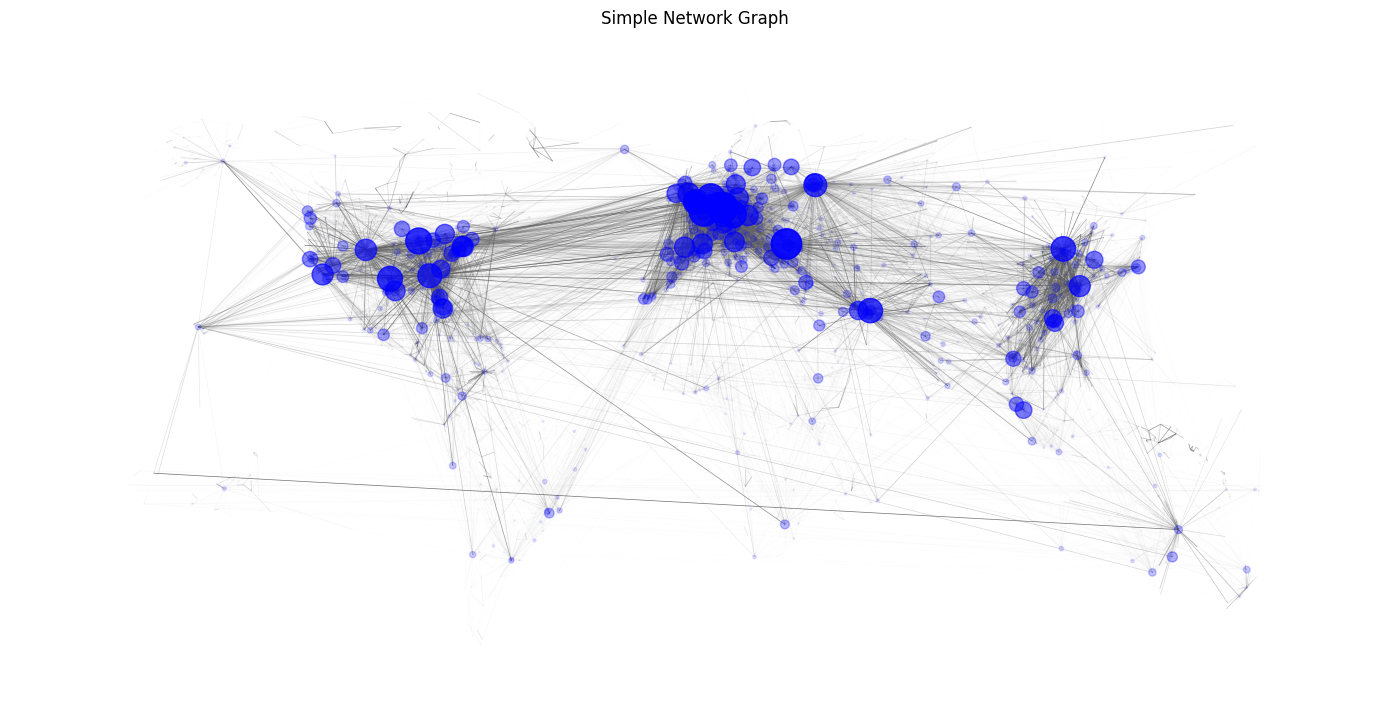

In [8]:
# Draw the graph
# Draw the graph using custom node positions
plt.figure(figsize=(14,7))

pos = nx.get_node_attributes(G,"location")

#labels = nx.get_node_attributes(G, 'country')
node_size = [0.005*G.degree[v]**2 for v in G]
#node_size=50
alpha = [0.003*G.degree[v] for v in G]
edge_width = [0.0015*G[u][v]['distance'] for u,v in G.edges()]


nx.draw_networkx(G, pos, alpha=alpha, with_labels=False, edge_color='0.4', node_color='blue', node_size = node_size, width=0.5)

plt.axis('off')
plt.tight_layout();
plt.title("Simple Network Graph")
plt.show()

In [9]:
def plot_detailed_graph(G, country_labels, emphasize_greater=True, degree_threshold=10, edge_highlight=None, labeled_nodes=True):
  # Draw the graph
  plt.figure(figsize=(14,7))
  pos = nx.get_node_attributes(G, "location")

  #degree_threshold = 10
  if emphasize_greater:
    filtered_nodes = [node for node in G.nodes() if G.degree[node] > degree_threshold]
  else:
    filtered_nodes = [node for node in G.nodes() if G.degree[node] < degree_threshold]
  filtered_edges = [(u, v) for u, v in G.edges() if u in filtered_nodes and v in filtered_nodes]

  filtered_node_degrees = {node: G.degree[node] for node in filtered_nodes}


  #node_size = 150
  node_size = [0.00005 * degree**3 for degree in filtered_node_degrees.values()]
  alpha = 1
  #alpha = [0.003 * G.degree[v] for v in G]
  edge_width = [0.00005 * G[u][v]['distance'] for u, v in G.edges()]

  # Draw only the filtered nodes and edges
  nx.draw_networkx_nodes(G, pos, nodelist=filtered_nodes, node_size=node_size, alpha=alpha, node_color='blue')
  nx.draw_networkx_edges(G, pos, edgelist=filtered_edges, width=edge_width, edge_color='0.5')

  if labeled_nodes:
    if emphasize_greater:
      nx.draw_networkx_labels(G, pos, labels=country_labels, font_size=10, font_color='yellow')
    else:
      nx.draw_networkx_labels(G, pos, labels=country_labels, font_size=10, font_color='black')

  if edge_highlight:
    if emphasize_greater:
      highlight_edges = [(u, v) for u, v in filtered_edges if G[u][v]['distance']>edge_highlight]
    else:
      highlight_edges = [(u, v) for u, v in filtered_edges if G[u][v]['distance']<edge_highlight]
    nx.draw_networkx_edges(G, pos, edgelist=highlight_edges, edge_color='r', alpha=1)

  #plt.axis('off')
  plt.tight_layout();
  plt.title("Airport Network Graph")
  plt.show()


degrees = dict(G.degree())



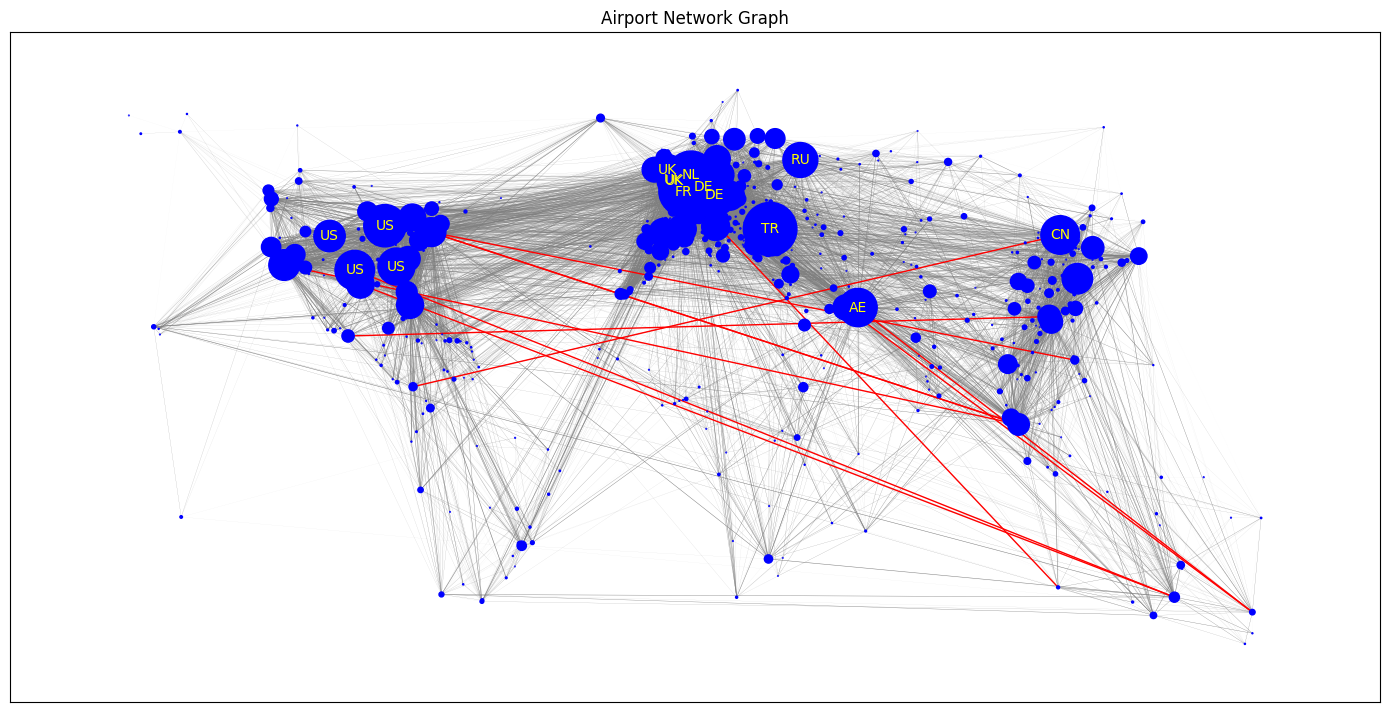

In [10]:
# @title Click Choose Params for Graph Display {run: "auto"}
emphasize_greater = True # @param {type:"boolean"}

# Sort nodes by degree in descending order and take the top 20
labeled_nodes = 15 #@param {type:"slider", min:0, max:100, step:5}
degree_threshold=15 #@param {type:"slider", min:0, max:200, step:5}
edge_highlight_threshold=8500 #@param {type:"slider", min:0, max:9000, step:50}

if labeled_nodes:
  if emphasize_greater :
    sorted_degrees = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[:labeled_nodes]
  else:
    sorted_degrees = sorted(degrees.items(), key=lambda x: x[1], reverse=True)[-labeled_nodes:]
# Create a dictionary with node number and "Country" attribute for the top 20 nodes
node_to_country = {node:G.nodes[node]["country"] for node, _ in sorted_degrees}

plot_detailed_graph(G, node_to_country, emphasize_greater=emphasize_greater, degree_threshold=degree_threshold,  edge_highlight=edge_highlight_threshold, labeled_nodes=labeled_nodes)

In [11]:
# Calculate and print node centralities, betweenness centralities, and closeness centralities
node_centralities = nx.degree_centrality(G)
betweenness_centralities = nx.betweenness_centrality(G)
closeness_centralities = nx.closeness_centrality(G)
def diameter_path():
  connected_components = list(nx.connected_components(G))
  for component_nodes in connected_components:
      subgraph = G.subgraph(component_nodes)
      #diameter = nx.diameter(subgraph)
      diameter_nodes = nx.center(subgraph)
      diameter = len(diameter_nodes)
      print(f"Diameter: {diameter} for this subgraph path: {diameter_nodes}")
#diameter_path()
##################print_highlight_edges

In [12]:
def print_metrics(reverse, count=15, node=False, betweenness=False, closeness=False, distances=False, total_airport_distances=False, distances_per_route=False):

  if node:
    sorted_node_centralities = sorted(node_centralities.items(), key=lambda x: x[1], reverse=reverse)
    print("Node Centralities (Normalized Number of Connections, for Dave: 5 Connections/8 Possible Connections):")
    for node, centrality in sorted_node_centralities[:count]:
        print(f"{node}: {G.nodes[node]['airport']} ({G.nodes[node]['city']},{G.nodes[node]['country']}): {centrality}")

  if betweenness:
    sorted_betweenness_centralities = sorted(betweenness_centralities.items(), key=lambda x: x[1], reverse=reverse)
    print("\nBetweenness Centralities (How often a node occurs on a path between two other node, Ex: How many people kind of know each other through Jim):")
    for node, centrality in sorted_betweenness_centralities[:count]:
        print(f"{node}: {G.nodes[node]['airport']} ({G.nodes[node]['city']},{G.nodes[node]['country']}): {centrality}")

  if closeness:
    sorted_closeness_centralities = sorted(closeness_centralities.items(), key=lambda x: x[1], reverse=reverse)
    print("""\nCloseness Centralities (How close a node is to all other nodes.
    Even if someone is not directly friends with everyone,is there a low number of
    edges required to connect them to others):""")
    for node, centrality in sorted_closeness_centralities[:count]:
        print(f"{node}: {G.nodes[node]['airport']} ({G.nodes[node]['city']},{G.nodes[node]['country']}): {centrality}")

  if distances:
    sorted_edges = sorted(G.edges(data=True), key=lambda x: x[2]['distance'], reverse=reverse)
    longest_flights = [(u, v)for u, v, _ in sorted_edges[:count]]
    print("\nLongest/Shortest Flights in the World")
    for u,v in longest_flights:
      print(f"{G.nodes[u]['airport']}({G.nodes[u]['city']},{G.nodes[u]['country']}) to {G.nodes[v]['airport']}({G.nodes[v]['city']},{G.nodes[v]['country']}): {int(G[u][v]['distance']):,} miles")

  if total_airport_distances:
    # Initialize a dictionary to store the sum of distances for each node
    sum_of_distances = {node: 0 for node in G.nodes}

    # Iterate through each edge and update the sum_of_distances dictionary
    for edge in G.edges(data='distance'):
      source, target, distance = edge
      sum_of_distances[source] += distance
      sum_of_distances[target] += distance
    sorted_totals = sorted(sum_of_distances.items(), key=lambda x: x[1], reverse=reverse)[:count]

    print("\nTotal Flight Distance")
    for u, value in sorted_totals:
      print(f"{G.nodes[u]['airport']}({G.nodes[u]['city']},{G.nodes[u]['country']}) has a total distance of all of it's routes of: {int(value):,} miles")

  if distances_per_route:
    sum_of_distances = {node: 0 for node in G.nodes}
    # Iterate through each edge and update the sum_of_distances dictionary
    for edge in G.edges(data='distance'):
      source, target, distance = edge
      sum_of_distances[source] += distance
      sum_of_distances[target] += distance
    keys_to_delete = [u for u in sum_of_distances.keys() if G.degree[u] == 0]
    for u in keys_to_delete:
      del sum_of_distances[u]
    for u, value in sum_of_distances.items():
      sum_of_distances[u]=value/G.degree(u)
    sorted_totals = sorted(sum_of_distances.items(), key=lambda x: x[1], reverse=reverse)[:count]
    print("\nAverage Distance per Route ")
    for u, value in sorted_totals:
      print(f"{G.nodes[u]['airport']}({G.nodes[u]['city']},{G.nodes[u]['country']}) has an average distance per route of: {int(value):,} miles for {G.degree(u)} routes")


In [13]:
# @title What to Print? {run: "auto"}
Top_Ranks = False#@param {type:"boolean"}
How_Many = 5 #@param {type:"slider", min:0, max:30, step:1}
Node_Centralities = True # @param {type:"boolean"}
Betweenness_Centralities = True # @param {type:"boolean"}
Closeness_Centralities = True # @param {type:"boolean"}
Flight_Distances = True # @param {type:"boolean"}
Total_Airport_Distances = True # @param {type:"boolean"}
Average_Airport_Distances_Per_Route = True # @param {type:"boolean"}


print_metrics(Top_Ranks, How_Many, Node_Centralities, Betweenness_Centralities, Closeness_Centralities, Flight_Distances, Total_Airport_Distances, Average_Airport_Distances_Per_Route)

Node Centralities (Normalized Number of Connections, for Dave: 5 Connections/8 Possible Connections):
200: Berlin, Tegel International Airport *Closed* (Berlin,DE): 0.0
473: Berlin-Schönefeld International Airport *Closed* (Berlin,DE): 0.0
942: New Castle Airport (Wilmington,US): 0.0
1008: Toowoomba Airport (Toowoomba,AU): 0.0
2537: Teniente Coronel Luis a Mantilla Airport (Tulcán,EC): 0.0

Betweenness Centralities (How often a node occurs on a path between two other node, Ex: How many people kind of know each other through Jim):
44: Santa Fe (Santa Fe,US): 0.0
191: Harrison, Boone County Airport (Harrison,US): 0.0
192: Salina Municipal Airport (Salina,US): 0.0
197: Sunshine Coast Airport (Maroochydore,AU): 0.0
200: Berlin, Tegel International Airport *Closed* (Berlin,DE): 0.0

Closeness Centralities (How close a node is to all other nodes.
    Even if someone is not directly friends with everyone,is there a low number of
    edges required to connect them to others):
200: Berlin, Tege

In [14]:
Atlanta = 1
Boston = 5
Washington_DC = 7
Washington_DC = 10
Orlando = 15
Houston = 11
NYC = 12
LA = 13
Chicago = 18
choice = Boston
print(f"Destinations FROM {G.nodes[choice]['airport']} ({G.nodes[choice]['city']}, {G.nodes[choice]['country']} ({G.degree(choice)} TOTAL))")
print("=========================================================================")
for neighbor in G.edges(choice):
    airport = G.nodes[neighbor[1]]['airport']
    city = G.nodes[neighbor[1]]['city']
    country = G.nodes[neighbor[1]]['country']
    print(f"{airport} ({city}, {country})")


Destinations FROM Boston Logan (Boston, US (143 TOTAL))
Hartsfield - Jackson Atlanta International Airport (Atlanta, US)
Austin Bergstrom International Airport (Austin, US)
Nashville International Airport (Nashville, US)
Baltimore/Washington International Airport (Baltimore, US)
Ronald Reagan Washington National Airport (Washington D.C., US)
Dallas/Fort Worth International Airport (Dallas, US)
Fort Lauderdale/Hollywood International Airport (Fort Lauderdale, US)
Washington Dulles International Airport (Washington D.C., US)
George Bush Intercontinental (Houston, US)
New York John F. Kennedy International Airport (New York, US)
Los Angeles International Airport (Los Angeles, US)
New York La Guardia (New York, US)
Orlando International Airport (Orlando, US)
Miami International Airport (Miami, US)
Minneapolis-St.Paul International Airport (Minneapolis, US)
Chicago O'Hare International Airport (Chicago, US)
Palm Beach International Airport (West Palm Beach, US)
Phoenix Sky Harbor Internatio

#Node2Vec Embeddings and Embeddings as a Tensor

In [15]:
def node2vec_embeddings(G, dimensions=128):
  node_index = list(G.nodes())
  # Use the Node2Vec algorithm to generate embeddings
  node2vec = Node2Vec(G, dimensions=dimensions, walk_length=25, num_walks=100, workers=4)

  # Embed nodes
  model = node2vec.fit(window=10, min_count=1)
  # Access the embeddings for nodes
  node_embeddings = [model.wv[node-1] for node in node_index]
  return node_embeddings

def random_embeddings(G, dimensions=128):
    node_index = list(G.nodes())

    # Generate random embeddings for each node
    node_embeddings = [np.random.rand(dimensions) for _ in node_index]

    return node_embeddings



In [16]:
def make_tensor(embedding_list):
  list_of_tensors = [tensor(embedding) for embedding in embedding_list]
  tensor_of_tensors = torch.stack(list_of_tensors, dim=0)
  return tensor_of_tensors

def make_double_tensor(embedding_list_1, embedding_list_2):
    #tensor_1 = tensor(embedding_list_1)
    #tensor_2 = tensor(embedding_list_2)
    combined_tensor = torch.cat((embedding_list_1, embedding_list_2), dim=1)
    return combined_tensor


node_embeddings = node2vec_embeddings(G)
#node_embeddings = random_embeddings(G)

#node_index = list(G.nodes())


#Choose Desired Embeddings and Make a tensor out of them

node2vec_tensor = make_tensor(node_embeddings)
location_tensor = make_tensor(list(nodes_df['location']))
double_tensor = make_double_tensor(node2vec_tensor, location_tensor)
print(f"Features shape: {double_tensor.shape}")

Computing transition probabilities:   0%|          | 0/3504 [00:00<?, ?it/s]

Features shape: torch.Size([3504, 130])


#Getting Positive and Negative Edges

In [17]:
# Get positive edges
dgl_graph = dgl.from_networkx(G)
pos_edges = list(G.edges())
np.random.shuffle(pos_edges)

# Split positive edges for training and testing
test_size = int(len(pos_edges) * 0.1)
train_size = int(len(pos_edges) * 0.9)

train_pos_edges, test_pos_edges = pos_edges[:train_size], pos_edges[-test_size:]

# Get negative edges
neg_edges = list(nx.non_edges(G))
np.random.shuffle(neg_edges)

# Split negative edges for training and testing
#3/4 the negative edges so that model does not always predict negative
train_neg_edges, test_neg_edges = neg_edges[:int(train_size*0.75)], neg_edges[int(-test_size*0.75):]

# Convert edges to arrays
train_pos_u, train_pos_v = zip(*train_pos_edges)
test_pos_u, test_pos_v = zip(*test_pos_edges)

train_neg_u, train_neg_v = zip(*train_neg_edges)
test_neg_u, test_neg_v = zip(*test_neg_edges)

all_pos_neg_edges = train_pos_edges + train_neg_edges + test_pos_edges + test_neg_edges
all_pos_neg_graph = dgl.graph(all_pos_neg_edges)

#Edge Embeddings

In [18]:
num_features = double_tensor.shape[1]*2

def edge_tensor(given_edges):
  temp_tensor = torch.empty((len(given_edges),num_features))
  #print(len(given_edges))
  for i, (u, v) in enumerate(given_edges):
      temp_tensor[i] = torch.cat((double_tensor[u-1], double_tensor[v-1]))
  return temp_tensor

train_pos_edge_tensors = edge_tensor(train_pos_edges)
train_neg_edge_tensors = edge_tensor(train_neg_edges)
test_pos_edge_tensors = edge_tensor(test_pos_edges)
test_neg_edge_tensors = edge_tensor(test_neg_edges)


#Edge Feature df

In [19]:
# Create DataFrames for positive and negative edges
train_pos_df = pd.DataFrame(train_pos_edge_tensors.numpy(), columns=[f'feature_{i}' for i in range(num_features)])
train_pos_df['label'] = True

train_neg_df = pd.DataFrame(train_neg_edge_tensors.numpy(), columns=[f'feature_{i}' for i in range(num_features)])
train_neg_df['label'] = False

test_pos_df = pd.DataFrame(test_pos_edge_tensors.numpy(), columns=[f'feature_{i}' for i in range(num_features)])
test_pos_df['label'] = True

test_neg_df = pd.DataFrame(test_neg_edge_tensors.numpy(), columns=[f'feature_{i}' for i in range(num_features)])
test_neg_df['label'] = False

# Concatenate positive and negative DataFrames for training and testing
train_df = pd.concat([train_pos_df, train_neg_df], ignore_index=True)
test_df = pd.concat([test_pos_df, test_neg_df], ignore_index=True)

# Shuffle the DataFrames (optional)
train_df = train_df.sample(frac=1)
test_df = test_df.sample(frac=1)

# Standard NN Model

In [20]:
from torch.utils.data import DataLoader, TensorDataset

# Extract features and labels
train_features = torch.tensor(train_df.drop('label', axis=1).values)
train_labels = torch.tensor(train_df['label'].values, dtype=torch.float32)

test_features = torch.tensor(test_df.drop('label', axis=1).values)
test_labels = torch.tensor(test_df['label'].values, dtype=torch.float32)



class standardNN(nn.Module):
    def __init__(self, in_feats):
        super(standardNN, self).__init__()
        self.linear1 = nn.Linear(in_feats, int(in_feats/2))
        self.linear2 = nn.Linear(int(in_feats/2), int(in_feats/4))
        self.linear3 = nn.Linear(int(in_feats/4), 1)
        self.dropout = nn.Dropout(0.35)

    def forward(self, edge_feats):
        # edge_feats: torch.Tensor (N, in_feats)
        x = F.relu(self.linear1(edge_feats))
        x = self.dropout(x)
        x = F.relu(self.linear2(x))
        x = self.dropout(x)
        pred = self.linear3(x)
        return pred

# Hyperparameters
in_feats = train_features.shape[1]

# Create Model
standard_link_pred = standardNN(in_feats)#, out_feats)

#GraphSAGE GNN Model

In [21]:
#GraphSAGE Model
class GraphSAGENet(nn.Module):
    def __init__(self, in_feats, hidden_feats, out_feats, num_layers):
        super(GraphSAGENet, self).__init__()
        self.layers = nn.ModuleList([
            dglnn.SAGEConv(in_feats, hidden_feats, 'mean')
            for _ in range(num_layers)
        ])
        self.dropout = nn.Dropout(0.35)
        self.prediction = nn.Linear(hidden_feats, out_feats)

    def forward(self, graph, x):
        for layer in self.layers:
            print(x.shape, graph.num_nodes(), graph.num_edges())
            x = F.relu(layer(graph, x))
            x = self.dropout(x)
        x = self.prediction(x)
        return x

#Hyper Parameters
node_features = double_tensor
in_feats = train_features.shape[1]
hidden_feats = int(in_feats/2)
num_layers = 3
out_feats = 1

#Create Model
GS_model = GraphSAGENet(in_feats,hidden_feats, out_feats, num_layers)


# Train Model

In [22]:
import torch.optim as optim

def train_model(model_choice):
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model_choice.parameters(), lr=0.01)

    num_epochs = 500

    for epoch in range(num_epochs):
        model_choice.train()
        optimizer.zero_grad()
        output = model_choice(train_features)
        loss = criterion(output.squeeze(), train_labels)
        loss.backward()
        optimizer.step()

        # Evaluate the model on the test set after each epoch
        model_choice.eval()
        #test_loss = 0.0
        with torch.no_grad():
            test_output = model_choice(test_features)
            test_loss = criterion(test_output.squeeze(), test_labels).item()

            #test_loss = batch_test_loss
        if (epoch+1) % 10 == 0:
            print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {loss.item():.2f}, Test Loss: {test_loss:.2f}')


train_model(standard_link_pred)
#train_model(GS_model)

Epoch 10/500, Train Loss: 0.53, Test Loss: 0.50
Epoch 20/500, Train Loss: 0.43, Test Loss: 0.37
Epoch 30/500, Train Loss: 0.38, Test Loss: 0.35
Epoch 40/500, Train Loss: 0.35, Test Loss: 0.32
Epoch 50/500, Train Loss: 0.34, Test Loss: 0.30
Epoch 60/500, Train Loss: 0.32, Test Loss: 0.29
Epoch 70/500, Train Loss: 0.30, Test Loss: 0.28
Epoch 80/500, Train Loss: 0.28, Test Loss: 0.27
Epoch 90/500, Train Loss: 0.27, Test Loss: 0.26
Epoch 100/500, Train Loss: 0.25, Test Loss: 0.25
Epoch 110/500, Train Loss: 0.24, Test Loss: 0.24
Epoch 120/500, Train Loss: 0.22, Test Loss: 0.23
Epoch 130/500, Train Loss: 0.21, Test Loss: 0.23
Epoch 140/500, Train Loss: 0.20, Test Loss: 0.22
Epoch 150/500, Train Loss: 0.19, Test Loss: 0.22
Epoch 160/500, Train Loss: 0.18, Test Loss: 0.21
Epoch 170/500, Train Loss: 0.17, Test Loss: 0.20
Epoch 180/500, Train Loss: 0.16, Test Loss: 0.20
Epoch 190/500, Train Loss: 0.15, Test Loss: 0.21
Epoch 200/500, Train Loss: 0.15, Test Loss: 0.20
Epoch 210/500, Train Loss: 0.

In [23]:
results = []
def link_prediction(departing_from, arriving_at, nn_model, actual):
  test_tensor = edge_tensor([(departing_from, arriving_at)])
  airport_one = nodes_df.loc[departing_from, ['airport','city', 'area_code']]
  airport_two = nodes_df.loc[arriving_at, ['airport','city', 'area_code']]
  #print(f"Direct Connection between: {airport_one[0]} {airport_one[1]}, {airport_one[2]} to {airport_two[0]} {airport_two[1]}, {airport_two[2]}")

  with torch.no_grad():
      nn_model.eval()
      pred = torch.sigmoid(nn_model(test_tensor))
  return departing_from, airport_one[0], f"{airport_one[1]}, {airport_one[2]}", arriving_at, airport_two[0], f"{airport_two[1]}, {airport_two[2]}", actual, round(pred.item(), 1)


for source, dest in test_pos_edges:
  results.append(link_prediction(source, dest, standard_link_pred, 1))
for source, dest in test_neg_edges:
  results.append(link_prediction(source, dest, standard_link_pred, 0))

columns = ['source','Airport One', 'City, Country One','dest', 'Airport Two', 'City, Country Two', 'Actual', 'Prediction']
predictions_df = pd.DataFrame(results, columns=columns)
predictions_df["Source_Degree"] = predictions_df["source"].map(G.degree)
predictions_df["Dest_Degree"] = predictions_df["dest"].map(G.degree)
predictions_df["Average_Degree"] = predictions_df.apply(lambda row: np.mean([G.degree(row['source']), G.degree(row['dest'])]), axis=1)
predictions_df = predictions_df.sort_values(by=['Average_Degree','Prediction'], ascending=False)

false_preds = predictions_df[np.abs(predictions_df['Actual']- predictions_df['Prediction'])>=0.3]
false_preds.to_csv("/content/drive/MyDrive/[3] Colab Notebooks/Airline Link Prediction GNN/pred_vs_actual.csv")
false_preds

,source,Airport One,"City, Country One",dest,Airport Two,"City, Country Two",Actual,Prediction,Source_Degree,Dest_Degree,Average_Degree
225,5,Boston Logan,"Boston, US",8,Dallas/Fort Worth International Airport,"Dallas, US",1,0.5,143,253,198.0
40,8,Dallas/Fort Worth International Airport,"Dallas, US",53,Helsinki Ventaa,"Helsinki, FI",1,0.7,253,130,191.5
651,79,Brussels Airport,"Brussels, BE",101,Suvarnabhumi Bangkok International Airport,"Bangkok, TH",1,0.5,194,153,173.5
1879,93,Stockholm-Arlanda Airport,"Stockholm, SE",101,Suvarnabhumi Bangkok International Airport,"Bangkok, TH",1,0.1,168,153,160.5
2317,129,Mombasa Moi International Airport,"Mombasa, KE",161,Istanbul International Airport,"Istanbul, TR",1,0.0,11,310,160.5
...,...,...,...,...,...,...,...,...,...,...,...
3211,1999,Namibe Airport,"Namibe, AO",3409,Kigoma Airport,"Kigoma, TZ",0,1.0,1,1,1.0
3302,2400,Taitung Airport,"Taitung City, TW",2758,Cox's Bazar Airport,"Cox's Bazar, BD",0,1.0,1,1,1.0
1324,3455,Barra do Garças Airport,"Barra Do Garças, BR",3456,Canarana Airport,"Canarana, BR",1,0.6,1,1,1.0
3050,1749,Kastelorizo Airport,"Kastelorizo Island, GR",3337,Kamishly Airport,"Kamishly, SY",0,0.6,1,1,1.0


1911 2133 2548 2326


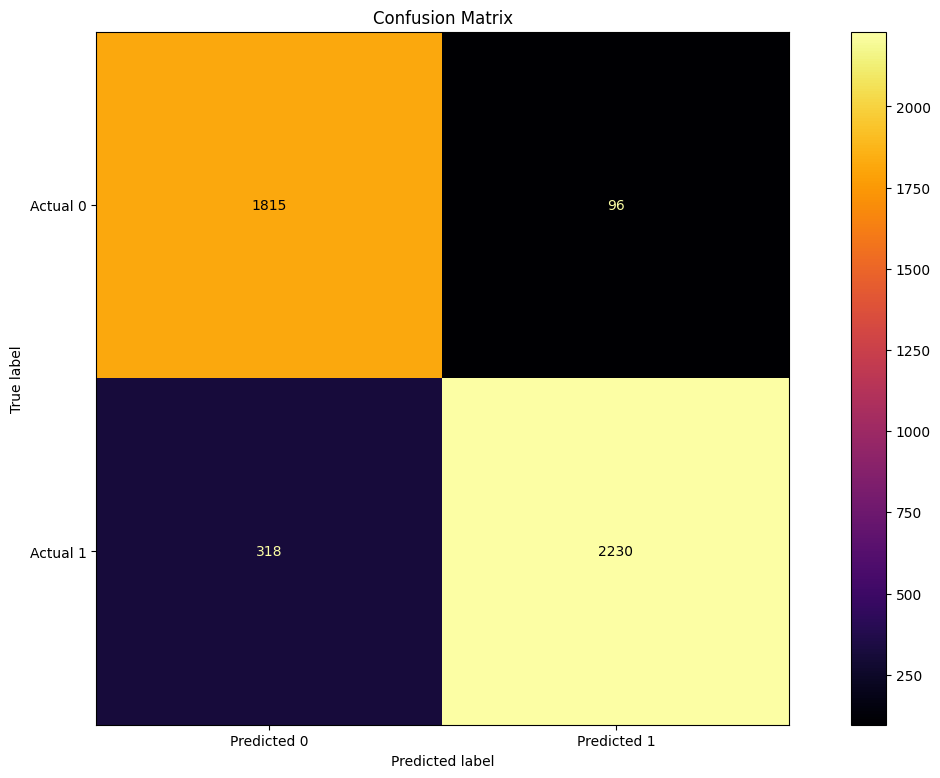

In [24]:
def plot_cm(predicted, actual, model_name):
  fig, ax = plt.subplots(figsize=(16, 9))
  print(sum(actual == 0), sum(predicted == 0), sum(actual == 1), sum(predicted == 1))
  ConfusionMatrixDisplay.from_predictions(actual, predicted, ax=ax, normalize=None, cmap='inferno')
  ax.set_xticklabels(['Predicted 0', 'Predicted 1'])
  ax.set_yticklabels(['Actual 0', 'Actual 1'])
  plt.title(model_name)
  plt.show()
plot_cm(predictions_df['Prediction'].astype(int), predictions_df['Actual'], "Confusion Matrix")

In [25]:
precision, recall, fscore, support = precision_recall_fscore_support(predictions_df['Actual'], predictions_df['Prediction'].astype(int), average='macro', zero_division=1)
accuracy = accuracy_score(predictions_df['Actual'], predictions_df['Prediction'].astype(int))
print(f"Accuracy: {accuracy*100 :.2f}%\nPrecision: {precision*100 :.2f}%\nRecall: {recall*100 :.2f}%\nfscore: {fscore*100 :.2f}%")

Accuracy: 90.72%
Precision: 90.48%
Recall: 91.25%
fscore: 90.63%


In [26]:
potential_new_connections = predictions_df[(predictions_df['Actual'] == 0) & (predictions_df['Prediction'] >= 0.90)]
new_links = list(zip(potential_new_connections['source'], potential_new_connections['dest']))
print(f"{len(potential_new_connections)} Potential New Connections")
potential_new_connections.to_csv("/content/drive/MyDrive/[3] Colab Notebooks/Airline Link Prediction GNN/potential_new.csv")
potential_new_connections
#print(new_links)

122 Potential New Connections


,source,Airport One,"City, Country One",dest,Airport Two,"City, Country Two",Actual,Prediction,Source_Degree,Dest_Degree,Average_Degree
3198,52,Frankfurt am Main,"Frankfurt, DE",1175,Bandar Lengeh Airport,"Bandar Lengeh, IR",0,1.0,310,2,156.0
3781,70,Amsterdam Airport Schiphol,"Amsterdam, NL",2267,Guriat Domestic Airport,"Guriat, SA",0,1.0,289,2,145.5
3871,80,Munich International Airport,"Munich, DE",1400,Brønnøysund Airport,"Brønnøy, NO",0,1.0,271,5,138.0
4164,80,Munich International Airport,"Munich, DE",2263,Al Baha Airport,"Al Baha, SA",0,1.0,271,3,137.0
3298,64,Beijing Capital International Airport,"Beijing, CN",3400,Nikolayevsk-na-Amure Airport,"Nikolayevsk-na-Amure, RU",0,1.0,249,1,125.0
...,...,...,...,...,...,...,...,...,...,...,...
3196,2398,Yap International Airport,"Yap Island, FM",2860,Bubung Airport,"Luwok-Celebes Island, ID",0,1.0,2,1,1.5
3508,1755,Naxos Airport,"Naxos Island, GR",2145,Çardak Airport,"Denizli, TR",0,1.0,1,2,1.5
2619,610,Southwest Georgia Regional Airport,"Albany, US",2193,Spring Point Airport,"Spring Point, BS",0,0.9,1,2,1.5
3211,1999,Namibe Airport,"Namibe, AO",3409,Kigoma Airport,"Kigoma, TZ",0,1.0,1,1,1.0


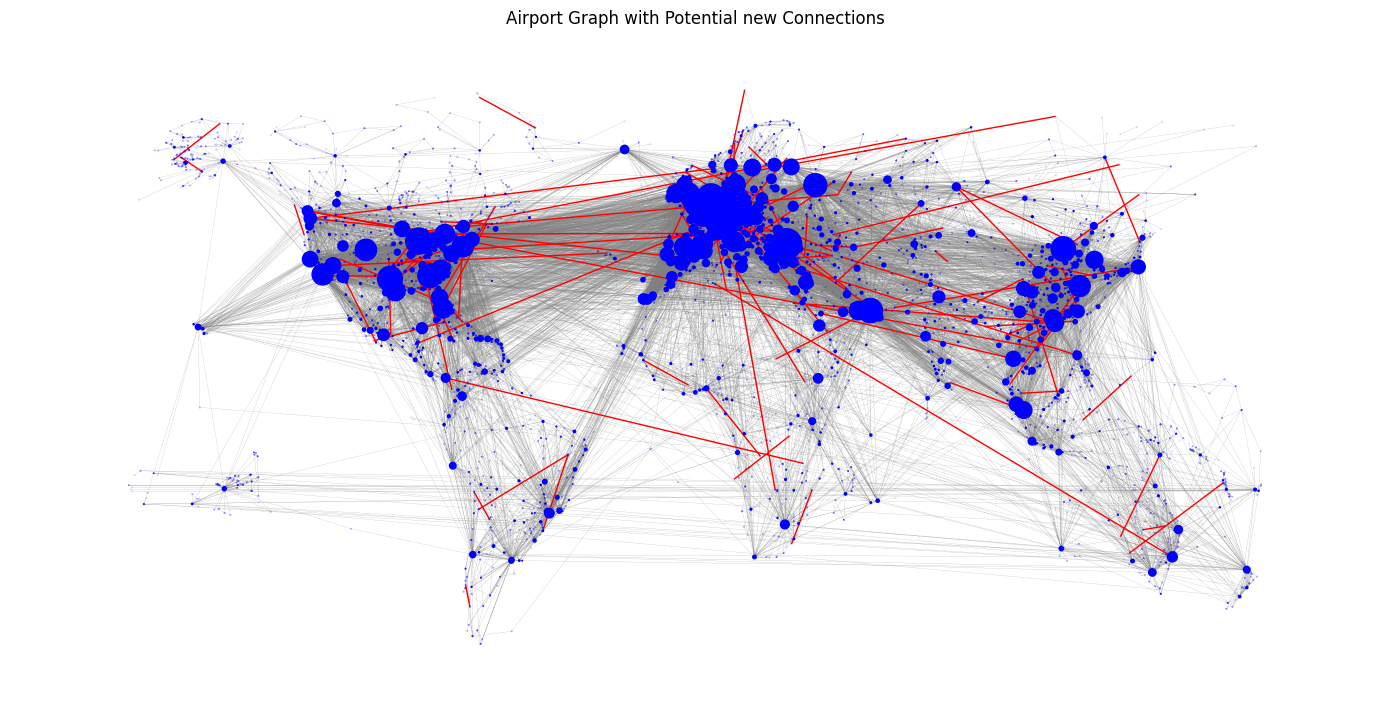

In [27]:
# Draw the graph
# Draw the graph using custom node positions
plt.figure(figsize=(14,7))

pos = nx.get_node_attributes(G,"location")

#labels = nx.get_node_attributes(G, 'country')
node_size = [0.005*G.degree[v]**2 for v in G]
#node_size=50
alpha = [0.003*G.degree[v] for v in G]
edge_width = [0.0015*G[u][v]['distance'] for u,v in G.edges()]


nx.draw_networkx(G, pos, alpha=1, with_labels=False, edge_color='0.5', node_color='blue', node_size = node_size, width=0.1)
nx.draw_networkx_edges(G, pos, edgelist=new_links, edge_color="red", width=1.0)

plt.axis('off')
plt.tight_layout();
plt.title("Airport Graph with Potential new Connections")
plt.show()